在这个工作是是将航班频次作为边的权重

## 加载数据

In [1]:
import pandas as pd

# 加载数据
data = pd.read_csv('../../data-hh/my/hh_result/result_all.csv')


# 查看前几行数据，确保加载成功
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5999225 entries, 0 to 5999224
Data columns (total 21 columns):
 #   Column      Dtype  
---  ------      -----  
 0   flt_no      object 
 1   bd_type     object 
 2   cap         float64
 3   aircraft    object 
 4   legs        int64  
 5   leg_no      int64  
 6   duration    float64
 7   pax         int64  
 8   a           object 
 9   b           object 
 10  c           object 
 11  year        int64  
 12  month       int64  
 13  day         int64  
 14  weekday     int64  
 15  hour        int64  
 16  minute      int64  
 17  second      int64  
 18  from        object 
 19  to          object 
 20  unit_price  float64
dtypes: float64(3), int64(10), object(8)
memory usage: 961.2+ MB
None


## 生成加权图

In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# 2. 创建空的有向图
G = nx.DiGraph()  # 使用 DiGraph 创建有向图

# 3. 计算每对城市之间的总客流量和航班数
# 使用一个字典来存储每对城市的客流量和航班数
city_pairs = {}

for index, row in data.iterrows():
    city_from = row['from']
    city_to = row['to']
    pax = row['pax']
    
    # 处理城市对的顺序，确保方向性
    if (city_from, city_to) not in city_pairs:
        city_pairs[(city_from, city_to)] = {'pax': pax, 'flights': 1}
    else:
        city_pairs[(city_from, city_to)]['pax'] += pax
        city_pairs[(city_from, city_to)]['flights'] += 1

# 4. 添加城市对为图的边，边的权重为平均客流量
for (city_from, city_to), data in city_pairs.items():
    average_pax = data['pax'] / data['flights']  # 计算平均客流量
    G.add_edge(city_from, city_to, weight=average_pax)

## 创建并训练 DeepWalk 模型

In [3]:
import networkx as nx
from node2vec import Node2Vec

1. 加载图并准备数据

In [4]:
# 通过 node2vec 包生成随机游走
node2vec = Node2Vec(G, dimensions=64, walk_length=3, num_walks=2000, workers=4, weight_key='weight')

# 训练模型
model = node2vec.fit(window=3, min_count=1, batch_words=4)

Computing transition probabilities:   0%|          | 0/252 [00:00<?, ?it/s]

Generating walks (CPU: 4): 100%|██████████| 500/500 [00:01<00:00, 413.44it/s]


2. 获取节点的嵌入向量

In [5]:
# 获取城市嵌入表示
city_embeddings = {}
for city in G.nodes():
    city_embeddings[city] = model.wv[city]  # 从模型中提取城市嵌入

# 打印第一个城市的嵌入表示
print(city_embeddings[list(G.nodes())[0]])

[ 0.26477784  0.23698288  0.19967414  0.01284393  0.00924978 -0.38968864
 -0.20309936 -0.05945505 -0.13429452  0.17624666  0.4358815  -0.20066452
 -0.32977316  0.04581654  0.661772    0.08073931 -0.1522767   0.21732403
  0.10332673 -0.02257106  0.6413088   0.59948426 -0.12970094 -0.41130382
  0.17672515  0.17609537 -0.39873153  0.09311176 -0.02385999  0.6075582
  0.5427167  -0.19870763  0.03200124 -0.05879742  0.14214562 -0.00526306
  0.25145376  0.14299428 -0.1358491   0.19254524  0.20325264  0.2530917
 -0.29846078  0.13524549 -0.19065411 -0.61888695  0.24135232 -0.3430288
  0.01987485 -0.01226378 -0.33034912  0.30896664  0.49726316  0.04780955
 -0.26382384  0.04901344  0.29347926 -0.30587494 -0.30064425  0.405725
  0.10609355 -0.12661467 -0.15511484  0.22160281]


## 进行聚类

步骤 3：使用嵌入向量进行下游任务（例如聚类）

In [6]:
from sklearn.cluster import KMeans
import numpy as np

# 提取嵌入向量
embeddings = np.array([city_embeddings[city] for city in G.nodes()])

# 使用 KMeans 聚类
kmeans = KMeans(n_clusters=3, random_state=42)  # 设置簇的数量为3
kmeans.fit(embeddings)

# 查看每个城市的聚类标签
city_labels = dict(zip(G.nodes(), kmeans.labels_))

# 打印城市及其对应的聚类标签
for city, label in city_labels.items():
    print(f"城市: {city}, 聚类标签: {label}")


城市: KNqX4/Q5Noc=, 聚类标签: 1
城市: HexFWXqbb8I=, 聚类标签: 0
城市: AKQNtuL5r6Q=, 聚类标签: 1
城市: Mv6HkAiSLUk=, 聚类标签: 1
城市: n465JzB8Rrw=, 聚类标签: 0
城市: N4hmDZN/CJQ=, 聚类标签: 1
城市: 5t+HPO9Mu/w=, 聚类标签: 0
城市: X5e5r3CS4OA=, 聚类标签: 1
城市: EF9aodHSh3E=, 聚类标签: 1
城市: iX2Pe2pxiqQ=, 聚类标签: 0
城市: lrbLyY7nRiw=, 聚类标签: 1
城市: vbo2dwBOeps=, 聚类标签: 1
城市: fl/vmiIcdls=, 聚类标签: 0
城市: a2cXIUGpIbw=, 聚类标签: 1
城市: Ne7JZ9C2ayc=, 聚类标签: 1
城市: XUXDuFGVfBM=, 聚类标签: 2
城市: tKjndGSl9NQ=, 聚类标签: 1
城市: xIqe+QQIQXQ=, 聚类标签: 1
城市: RTA+2OkM90I=, 聚类标签: 0
城市: KETr2NAmAHE=, 聚类标签: 0
城市: OJ0BsQ7KlKk=, 聚类标签: 1
城市: So/c8CkA/Xs=, 聚类标签: 0
城市: Lue5PP9SfQU=, 聚类标签: 1
城市: h9GisD/ZayE=, 聚类标签: 0
城市: zwVGiYamVc0=, 聚类标签: 1
城市: /qxKZMQeBus=, 聚类标签: 1
城市: DUbxF00Y8a0=, 聚类标签: 1
城市: Y50ETJ8qYSE=, 聚类标签: 0
城市: QyEgIt0M8Sg=, 聚类标签: 1
城市: xRL77yJN1tk=, 聚类标签: 1
城市: hwin1ipuzwk=, 聚类标签: 1
城市: CnmNtb5MOJA=, 聚类标签: 1
城市: 9j4ofoSZvc4=, 聚类标签: 1
城市: Qe7TEMbQt6o=, 聚类标签: 0
城市: tiwC3iWlaiU=, 聚类标签: 0
城市: g1hKMyP1V8I=, 聚类标签: 1
城市: /M8gHzjxpNU=, 聚类标签: 1
城市: wSF4qXvI044=, 聚类标签: 1
城市: grkgazDv

## 二维空间聚类效果展示

步骤 4：可视化嵌入

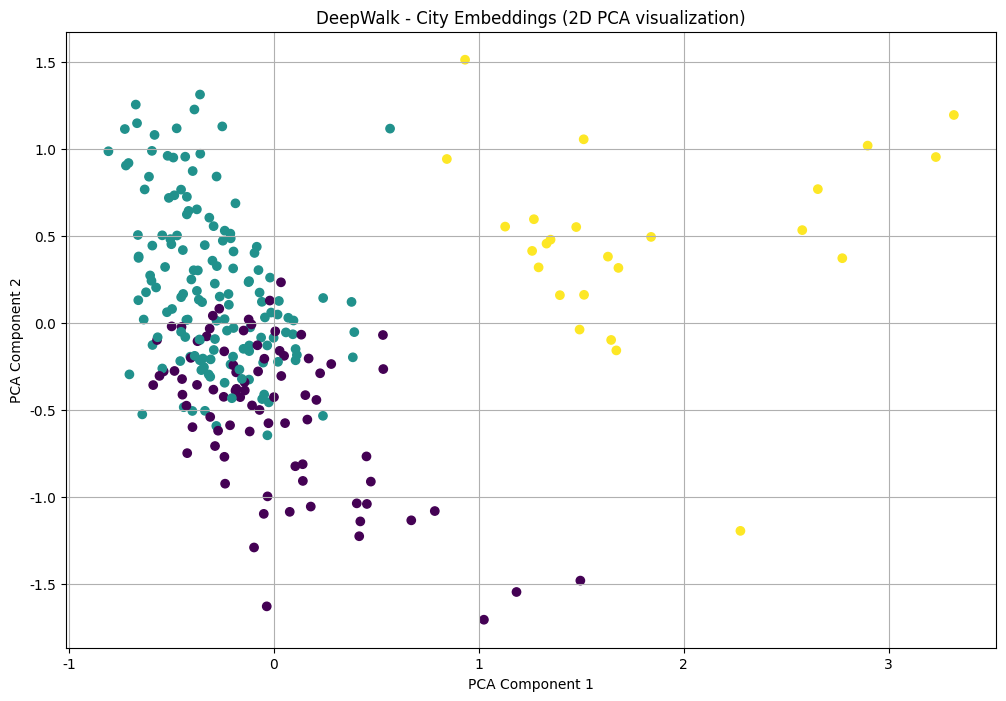

In [7]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 使用 PCA 降维到 2D
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embeddings)

# 绘制散点图
plt.figure(figsize=(12, 8))
plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], c=kmeans.labels_, cmap='viridis')

# 去掉为每个城市添加标签的部分
# for i, city in enumerate(G.nodes()):
#     plt.text(reduced_embeddings[i, 0] + 0.1, reduced_embeddings[i, 1] + 0.1, city, fontsize=9)

plt.title("DeepWalk - City Embeddings (2D PCA visualization)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()


In [8]:
from sklearn.metrics.pairwise import cosine_similarity

# 计算城市之间的相似度
similarity_matrix = cosine_similarity(embeddings)

# 打印第一个城市和其他城市的相似度
for i, city in enumerate(G.nodes()):
    print(f"城市: {city}, 相似度: {similarity_matrix[0, i]}")

城市: KNqX4/Q5Noc=, 相似度: 1.000000238418579
城市: HexFWXqbb8I=, 相似度: -0.04042569920420647
城市: AKQNtuL5r6Q=, 相似度: 0.21332961320877075
城市: Mv6HkAiSLUk=, 相似度: 0.20373837649822235
城市: n465JzB8Rrw=, 相似度: -0.0038530000019818544
城市: N4hmDZN/CJQ=, 相似度: 0.14845268428325653
城市: 5t+HPO9Mu/w=, 相似度: 0.11244016140699387
城市: X5e5r3CS4OA=, 相似度: 0.5497964024543762
城市: EF9aodHSh3E=, 相似度: 0.26992103457450867
城市: iX2Pe2pxiqQ=, 相似度: 0.24051623046398163
城市: lrbLyY7nRiw=, 相似度: 0.49808892607688904
城市: vbo2dwBOeps=, 相似度: 0.0962238684296608
城市: fl/vmiIcdls=, 相似度: 0.1728551685810089
城市: a2cXIUGpIbw=, 相似度: 0.08256671577692032
城市: Ne7JZ9C2ayc=, 相似度: 0.21616202592849731
城市: XUXDuFGVfBM=, 相似度: 0.10843706130981445
城市: tKjndGSl9NQ=, 相似度: 0.1629151850938797
城市: xIqe+QQIQXQ=, 相似度: 0.1388661116361618
城市: RTA+2OkM90I=, 相似度: 0.14411379396915436
城市: KETr2NAmAHE=, 相似度: 0.2014237493276596
城市: OJ0BsQ7KlKk=, 相似度: 0.3340001702308655
城市: So/c8CkA/Xs=, 相似度: 0.14564508199691772
城市: Lue5PP9SfQU=, 相似度: 0.2408779412508011
城市: h9GisD/ZayE=,

轮廓系数是评估聚类质量的常用指标，范围是 -1 到 1，值越大表示聚类效果越好。它同时考虑了簇内紧密度（每个点与所在簇中其他点的距离）和簇间分离度（每个点与最近簇的距离）。

值的意义：

值接近 +1：说明数据点与同簇内的点很接近，且与其他簇的点有很大区别，聚类效果好。

值接近 0：表示数据点可能位于两个簇的边界上，聚类效果一般。

值接近 -1：表示数据点可能被错误地归类到某个簇中，聚类效果差。

In [9]:
from sklearn.metrics import silhouette_score
score = silhouette_score(reduced_embeddings, kmeans.labels_)
print(f'Silhouette Score: {score}')

Silhouette Score: 0.2397327870130539
